In [1]:
import sys
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Add root directory to path
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))

# Import all functions from technology_diffusion modules
from src.technology_diffusion.helpers import (
    suppress_print,
    resume_print,
    time_exceeded,
    make_vector,
    create_pa_graph,
    make_subset_connected,
    connected_component_update,
    connected_component_spread,
)

from src.technology_diffusion.heuristics import (
    SingleDiscount,
    degree,
    degree_threshold,
    betweenness,
    degree_connected,
    high_thetas,
    degree_discount,
    random_start,
    technology_diffusion_heuristics,
)

from src.technology_diffusion.ip_problems import (
    build_golberg_liu_ip,
    get_activation_sequence_and_seeds,
    build_exact_ip,
)

from src.technology_diffusion.nads import (
    NaDS_td,
    NaDS_technology_diffusion_binary_search,
)

In [ ]:
N=6, c=5, seed=42, init_nodes=5, init_mode=complete

In [8]:
n_nodes = 2000
k = 200
c = 5

delta = 0.5
xi = 0.1
d = 2
min_conn = 10
mg_max_depth = 3
mg_memory_len = 5

max_time = 10
buffer_dim = 5000
seed = 1
g, thetas = create_pa_graph(n_nodes, c, seed, init_nodes=5, init_mode='complete')

for i in range(10):

    x0 = random_start(g, n_nodes, k, thetas, 1)
    

    # s, final_x, _ = NaDS_td(g, thetas, x0, delta, xi, d, min_conn, mg_max_depth, mg_memory_len, max_time, buffer_dim, 1)

    print(sum(x0))

200.0
200.0
200.0
200.0
200.0
200.0
200.0
200.0
200.0
200.0


In [39]:
final_spread, spread_hist, final_x = connected_component_spread(g, x0, thetas)
print(f"Final spread: {final_spread}, Spread history: {spread_hist}")


Final spread: 3, Spread history: [3]


In [40]:
_, h_k, h_runtime, h_history = technology_diffusion_heuristics(g, n_nodes, thetas, 1, high_thetas)
print(f"Heuristic k: {h_k}, Heuristic runtime: {h_runtime}, Heuristic history: {h_history}")

Heuristic k: 4, Heuristic runtime: 0.0006, Heuristic history: [(6, 0.0), (6, 0.0004), (4, 0.0006), (4, 0.0006)]


In [41]:
strategy = [
        high_thetas,
        degree_threshold,
        degree_discount,
        degree_connected,
        degree,
        betweenness,
        random_start,
    ]

nads_k, final_x, nads_runtime, nads_history = NaDS_technology_diffusion_binary_search(
                g,
                thetas,
                strategy,
                delta,
                xi,
                d,
                min_conn,
                mg_max_depth,
                mg_memory_len,
                max_time,
                buffer_dim,
                1,
            )

Binary search... Done! k:3. Time: 10/10 s.                                


In [42]:
final_x

array([0., 1., 1., 1., 0., 1.])

In [2]:
N_list = [200, 500, 1000, 2000]
c_list = [2, 4]
seed_list = [7, 42, 99]
K_fracs = [0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

heuristics = [
    ("degree", degree, [0, 1]),
    ("degree_threshold", degree_threshold, [0, 1]),
    ("high_thetas", high_thetas, [0, 1]),
    ("degree_discount", degree_discount, [0, 1]),
    ("random_start", random_start, [0, 1]),
    ("degree_connected", degree_connected, [None]),
]

def make_k_list(N, fracs):
    ks = sorted({max(1, int(round(N * f))) for f in fracs})
    ks = [k for k in ks if k < N]
    return ks

rows = []
run_start = time.time()

for N in N_list:
    K_list = make_k_list(N, K_fracs)

    for c in c_list:
        for seed in seed_list:
            g, thetas = create_pa_graph(n_nodes=N, c=c, seed=seed, init_nodes=5, init_mode="complete")

            for K in K_list:
                for h_name, h_fun, conn_values in heuristics:
                    for conn in conn_values:
                        random.seed(seed + 10_000 + K)
                        np.random.seed(seed + 20_000 + K)

                        t0 = time.time()
                        if conn is None:
                            x0 = h_fun(g, N, K, thetas=thetas, connected=None)
                            conn_label = "intrinsic"
                        else:
                            x0 = h_fun(g, N, K, thetas=thetas, connected=conn)
                            conn_label = str(conn)

                        spread, _, _ = connected_component_spread(g, x0, thetas, max_t=1000)
                        elapsed = time.time() - t0

                        rows.append({
                            "N": N,
                            "c": c,
                            "seed": seed,
                            "K": K,
                            "K_over_N": K / N,
                            "heuristic": h_name,
                            "connected": conn_label,
                            "heuristic_variant": f"{h_name} | connected={conn_label}",
                            "spread": int(spread),
                            "spread_ratio": spread / N,
                            "runtime_s": elapsed,
                        })
                        print(f"Completed: N={N}, c={c}, seed={seed}, K={K}, heuristic={h_name}, connected={conn_label}, spread={spread}, runtime={round(elapsed, 2)}s")

results_heuristics_df = pd.DataFrame(rows)

print(f"Completed {len(results_heuristics_df)} runs in {round(time.time() - run_start, 2)} seconds.")
display(results_heuristics_df.head(10))

# Optional save
save_csv = False
csv_path = "heuristics_pa_comparison.csv"
if save_csv:
    results_heuristics_df.to_csv(csv_path, index=False)
    print(f"Saved results to {csv_path}")


Completed: N=200, c=2, seed=7, K=4, heuristic=degree, connected=0, spread=12, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=degree, connected=1, spread=12, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=degree_threshold, connected=0, spread=12, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=degree_threshold, connected=1, spread=12, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=high_thetas, connected=0, spread=5, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=high_thetas, connected=1, spread=8, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=degree_discount, connected=0, spread=10, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=degree_discount, connected=1, spread=10, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=random_start, connected=0, spread=4, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4, heuristic=random_start, connected=1, spread=7, runtime=0.0s
Completed: N=200, c=2, seed=7, K=4

,N,c,seed,K,K_over_N,heuristic,connected,heuristic_variant,spread,spread_ratio,runtime_s
0,200,2,7,4,0.02,degree,0,degree | connected=0,12,0.060,0.001398
1,200,2,7,4,0.02,degree,1,degree | connected=1,12,0.060,0.003560
2,200,2,7,4,0.02,degree_threshold,0,degree_threshold | connected=0,12,0.060,0.001221
3,200,2,7,4,0.02,degree_threshold,1,degree_threshold | connected=1,12,0.060,0.001914
4,200,2,7,4,0.02,high_thetas,0,high_thetas | connected=0,5,0.025,0.000268
5,200,2,7,4,0.02,high_thetas,1,high_thetas | connected=1,8,0.040,0.001589
6,200,2,7,4,0.02,degree_discount,0,degree_discount | connected=0,10,0.050,0.001673
7,200,2,7,4,0.02,degree_discount,1,degree_discount | connected=1,10,0.050,0.002111
8,200,2,7,4,0.02,random_start,0,random_start | connected=0,4,0.020,0.000127
9,200,2,7,4,0.02,random_start,1,random_start | connected=1,7,0.035,0.001310


Top variants by (N, K):


,N,K,K_over_N,heuristic_variant,mean_spread,std_spread,mean_spread_ratio,mean_runtime_s,n_runs
5,200,4,0.02,degree_threshold | connected=0,7.166667,3.060501,0.035833,0.000538,6
6,200,4,0.02,degree_threshold | connected=1,7.166667,3.060501,0.035833,0.001141,6
0,200,4,0.02,degree | connected=0,6.666667,3.444803,0.033333,0.000508,6
15,200,10,0.05,degree_discount | connected=1,21.666667,11.129540,0.108333,0.003570,6
14,200,10,0.05,degree_discount | connected=0,21.333333,11.430952,0.106667,0.002024,6
...,...,...,...,...,...,...,...,...,...
294,2000,800,0.40,high_thetas | connected=1,2000.000000,0.000000,1.000000,2.966236,6
291,2000,800,0.40,degree_threshold | connected=0,1999.666667,0.816497,0.999833,0.007934,6
304,2000,1000,0.50,high_thetas | connected=0,2000.000000,0.000000,1.000000,0.004865,6
305,2000,1000,0.50,high_thetas | connected=1,2000.000000,0.000000,1.000000,3.857650,6


Average performance across all settings:


,heuristic_variant,mean_spread_ratio,std_spread_ratio,mean_runtime_s,n_runs
5,degree_threshold | connected=0,0.742042,0.398396,0.008561,168
6,degree_threshold | connected=1,0.741735,0.398926,0.479685,168
4,degree_discount | connected=1,0.689875,0.399664,0.543712,168
2,degree_connected | connected=intrinsic,0.680616,0.400091,0.254686,168
0,degree | connected=0,0.679562,0.399808,0.010712,168
1,degree | connected=1,0.679557,0.399817,0.462604,168
8,high_thetas | connected=1,0.671750,0.436398,0.518249,168
10,random_start | connected=1,0.666179,0.423299,0.516616,168
3,degree_discount | connected=0,0.656836,0.401989,0.028169,168
7,high_thetas | connected=0,0.568054,0.466698,0.003031,168


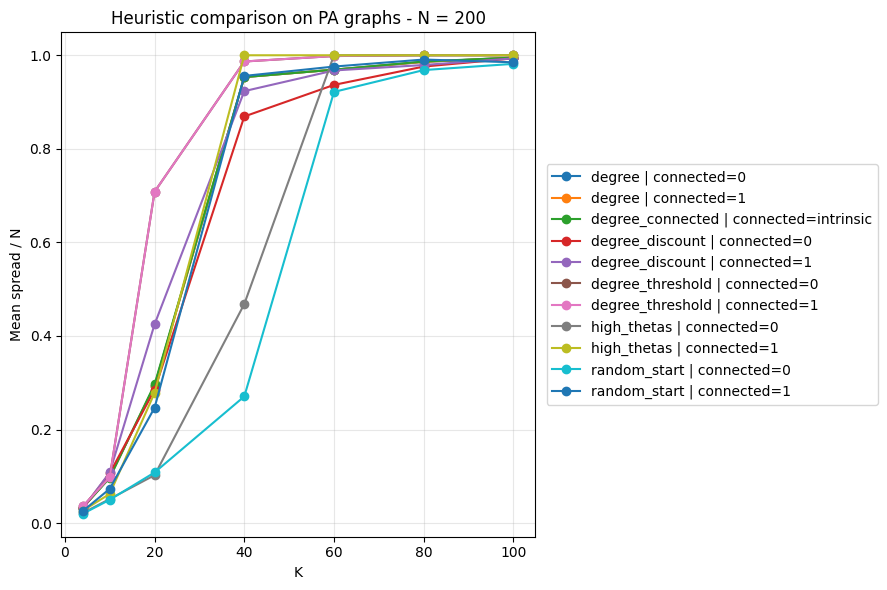

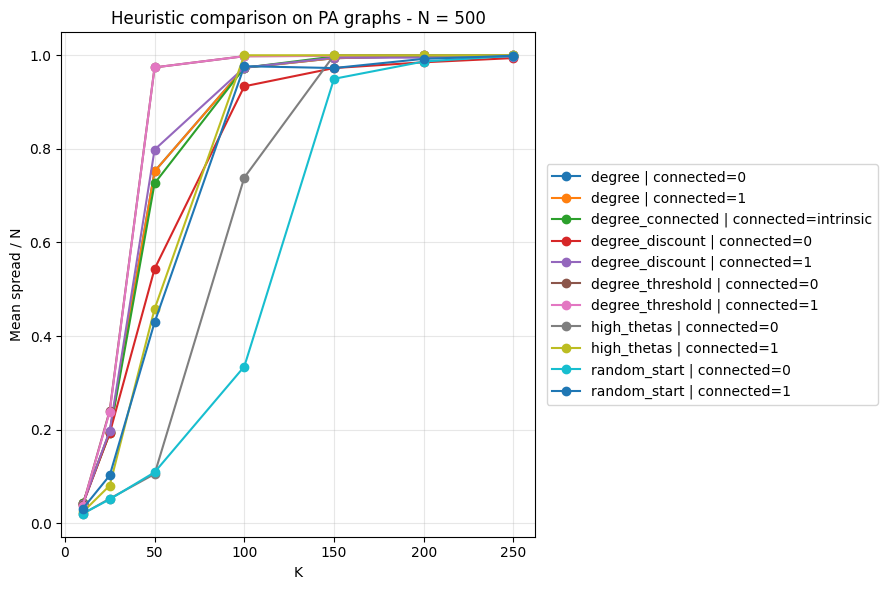

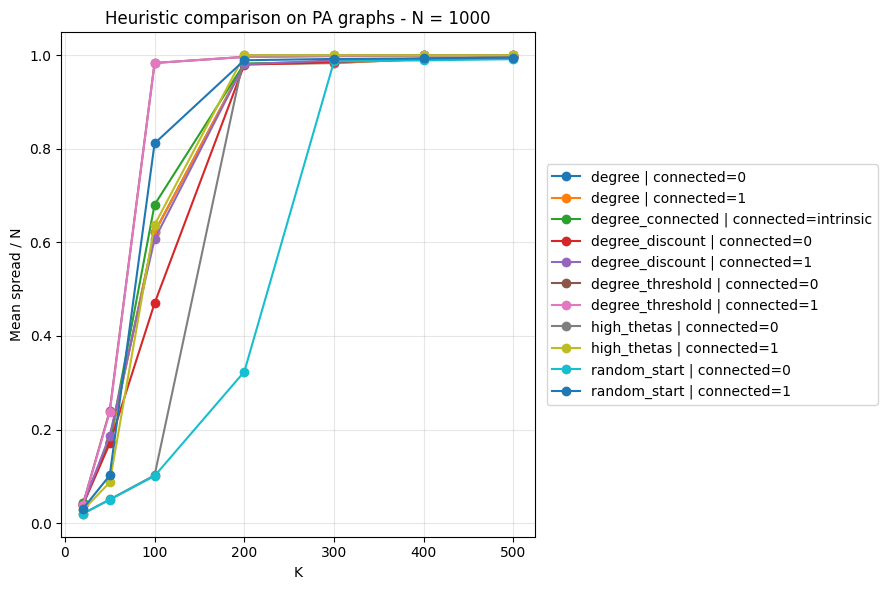

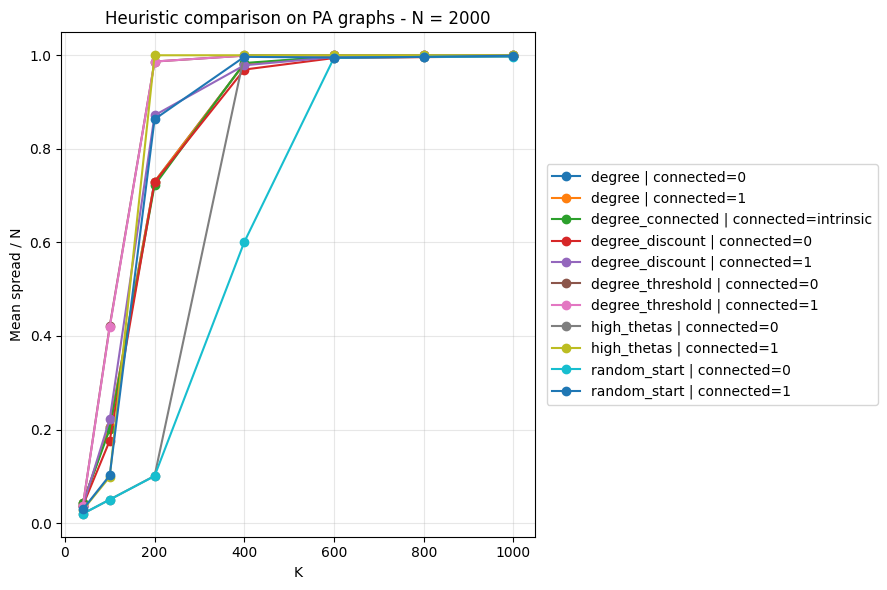

,heuristic_variant,mean_spread_ratio,mean_runtime_s
5,degree_threshold | connected=0,0.742042,0.008561
6,degree_threshold | connected=1,0.741735,0.479685
4,degree_discount | connected=1,0.689875,0.543712
2,degree_connected | connected=intrinsic,0.680616,0.254686
0,degree | connected=0,0.679562,0.010712
1,degree | connected=1,0.679557,0.462604
8,high_thetas | connected=1,0.671750,0.518249
10,random_start | connected=1,0.666179,0.516616
3,degree_discount | connected=0,0.656836,0.028169
7,high_thetas | connected=0,0.568054,0.003031


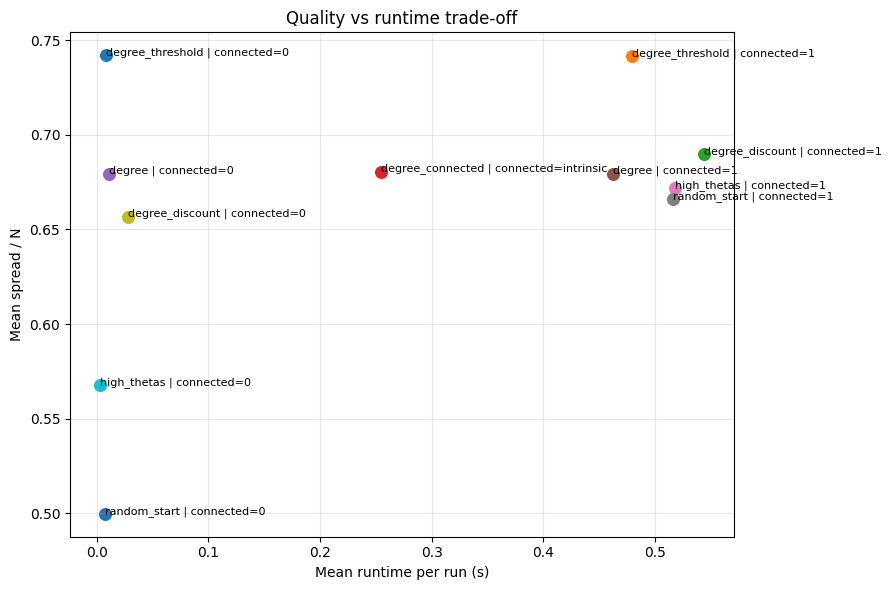

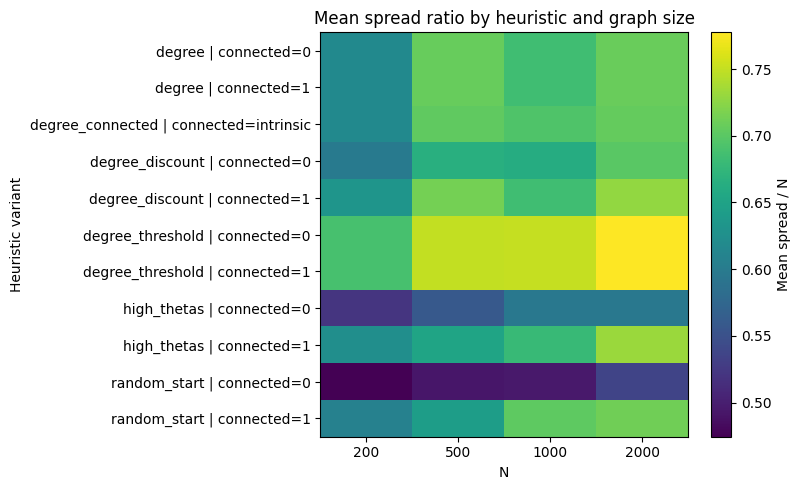

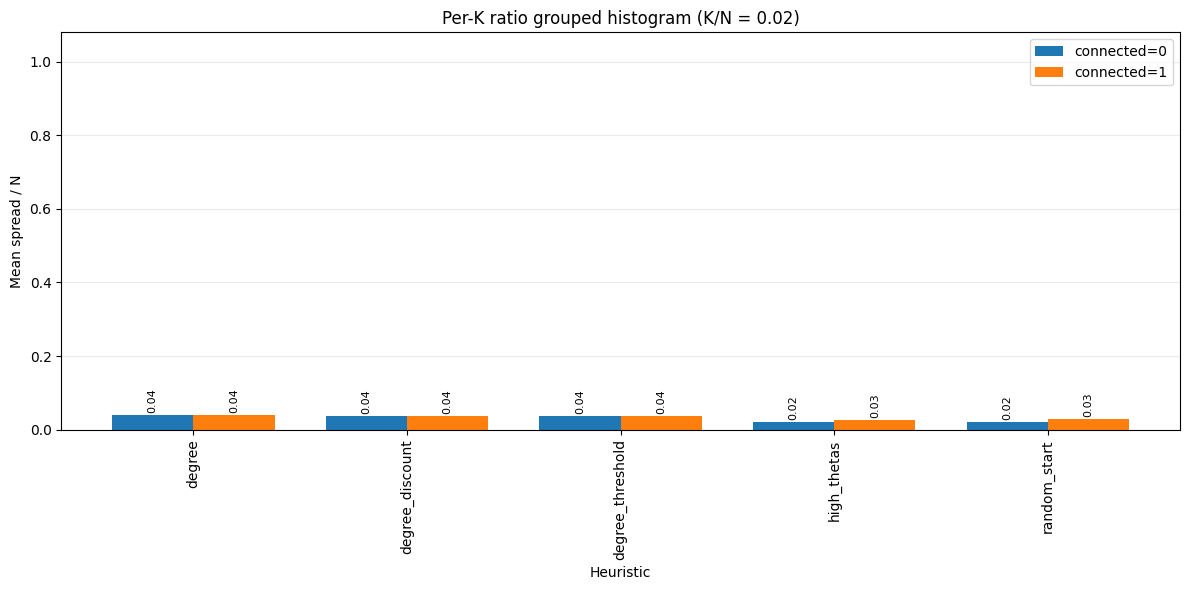

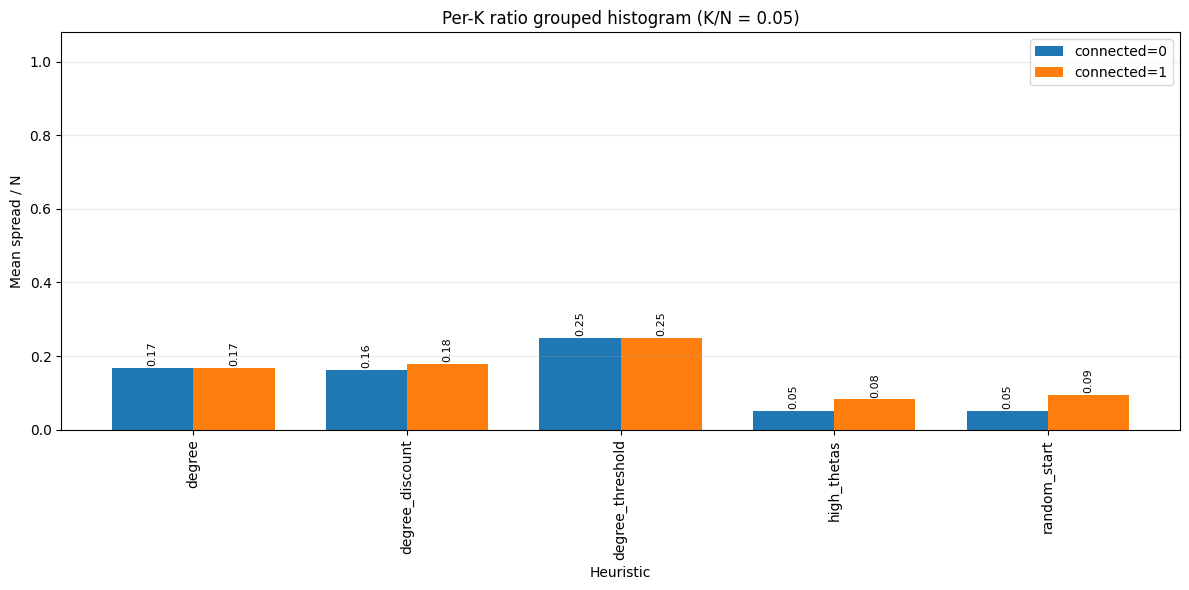

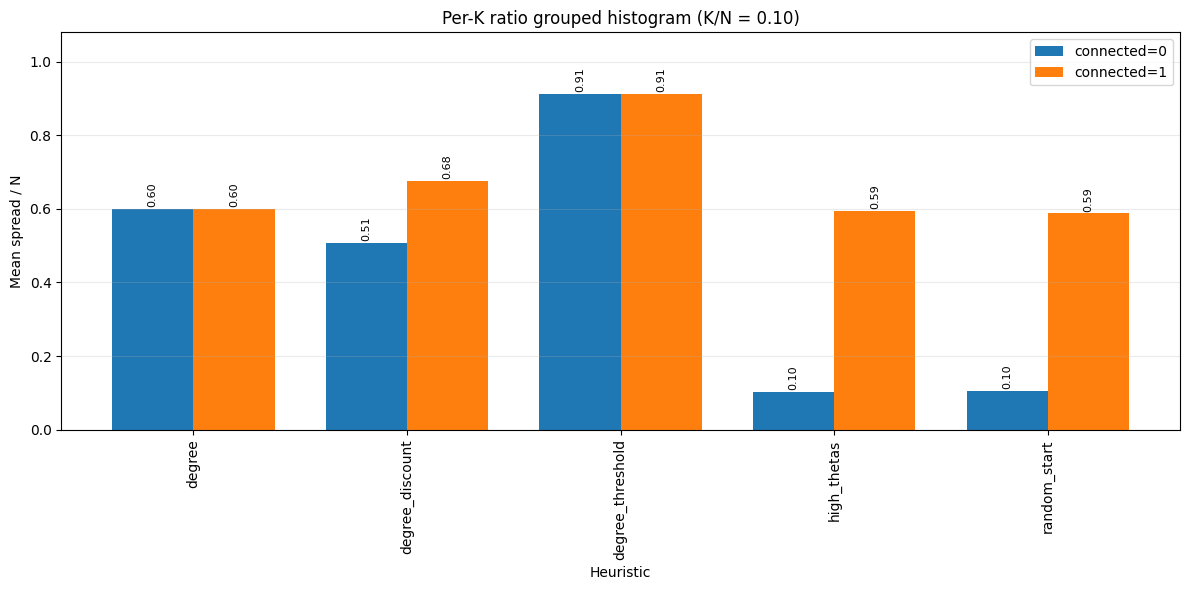

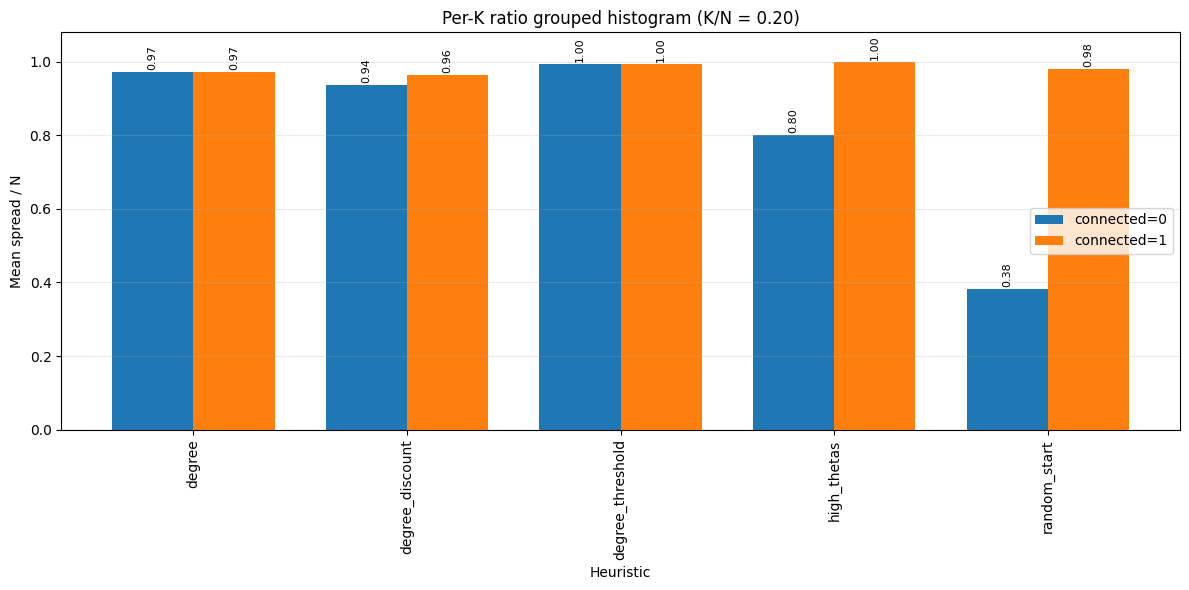

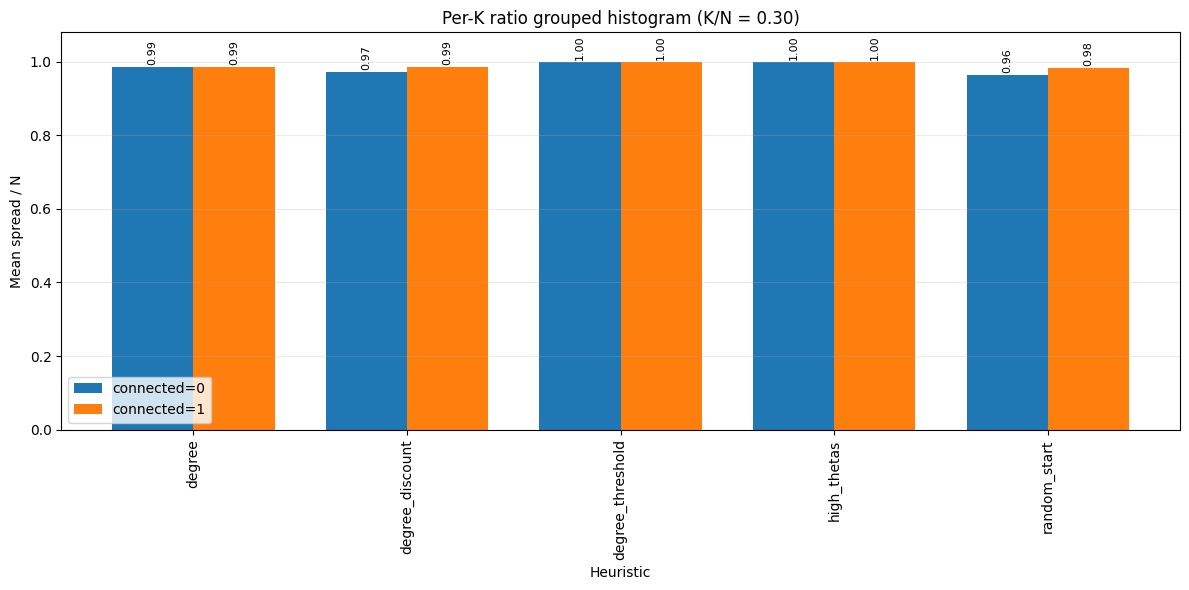

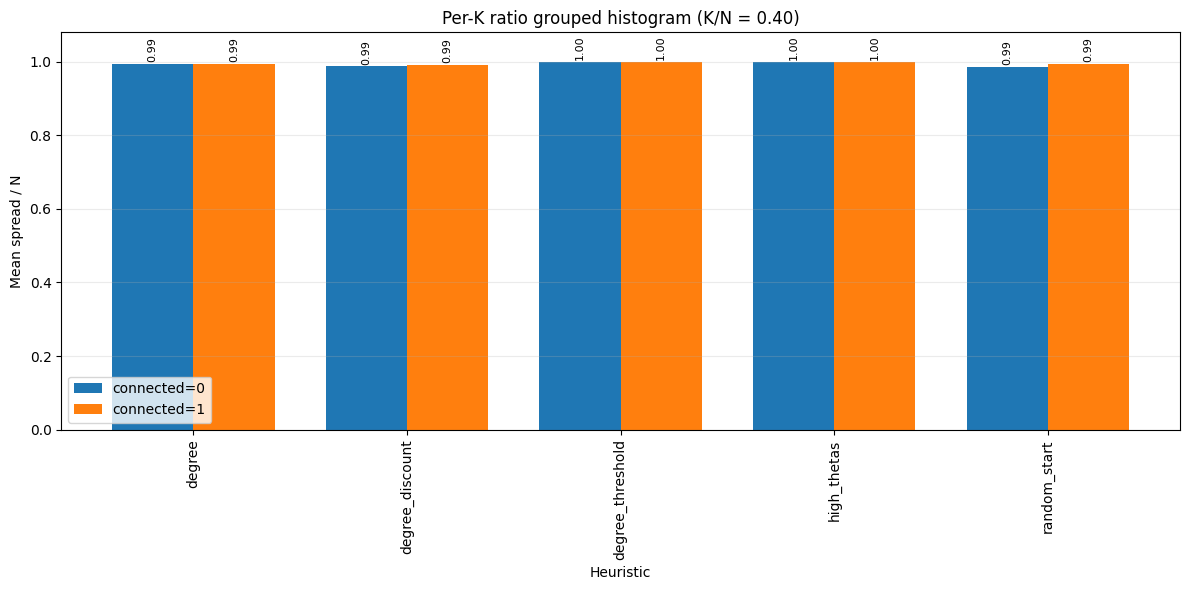

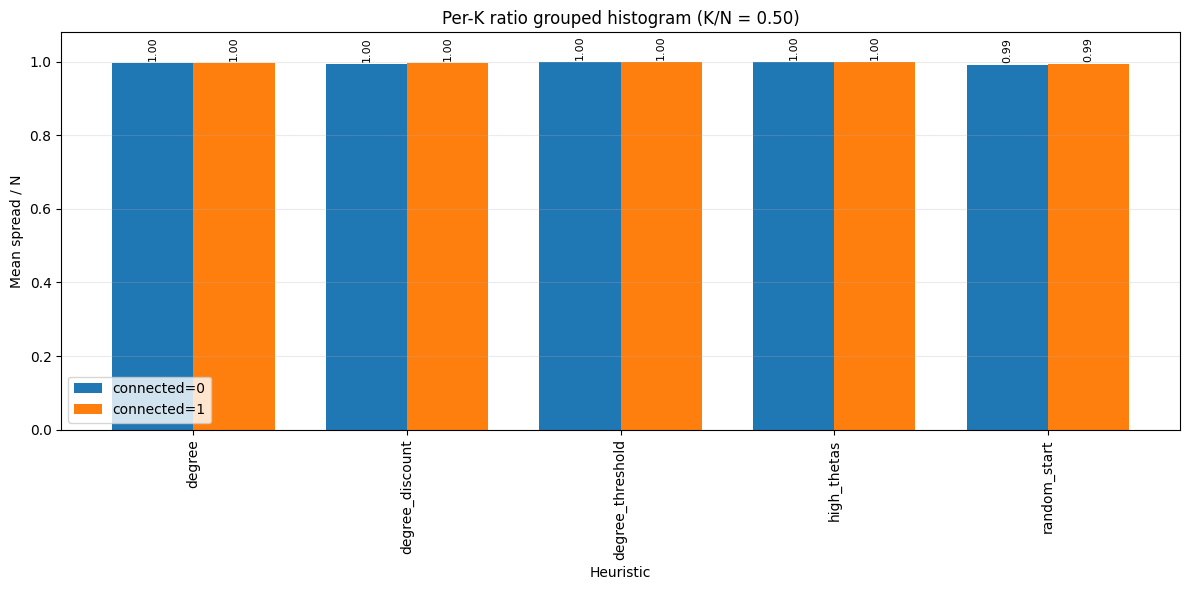

In [3]:
# Summaries + visualization (spread + time)
if "results_heuristics_df" not in globals() or results_heuristics_df.empty:
    raise ValueError("Run the benchmark cell first to populate results_heuristics_df.")

summary_df = (
    results_heuristics_df
    .groupby(["N", "K", "K_over_N", "heuristic_variant"], as_index=False)
    .agg(
        mean_spread=("spread", "mean"),
        std_spread=("spread", "std"),
        mean_spread_ratio=("spread_ratio", "mean"),
        mean_runtime_s=("runtime_s", "mean"),
        n_runs=("spread", "count"),
    )
    .sort_values(["N", "K", "mean_spread_ratio"], ascending=[True, True, False])
)

print("Top variants by (N, K):")
top_by_group = summary_df.groupby(["N", "K"], as_index=False).head(3)
display(top_by_group)

print("Average performance across all settings:")
overall_df = (
    results_heuristics_df
    .groupby("heuristic_variant", as_index=False)
    .agg(
        mean_spread_ratio=("spread_ratio", "mean"),
        std_spread_ratio=("spread_ratio", "std"),
        mean_runtime_s=("runtime_s", "mean"),
        n_runs=("spread_ratio", "count"),
    )
    .sort_values("mean_spread_ratio", ascending=False)
)
display(overall_df)

# Plot 1: mean spread ratio vs K (one separate figure per N)
N_values = sorted(results_heuristics_df["N"].unique())
for N in N_values:
    plt.figure(figsize=(9, 6))
    data_N = summary_df[summary_df["N"] == N]

    for hv, sub in data_N.groupby("heuristic_variant"):
        sub = sub.sort_values("K")
        plt.plot(sub["K"], sub["mean_spread_ratio"], marker="o", label=hv)

    plt.title(f"Heuristic comparison on PA graphs - N = {N}")
    plt.xlabel("K")
    plt.ylabel("Mean spread / N")
    plt.grid(alpha=0.3)
    plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    plt.tight_layout()
    plt.show()

# Plot 2: quality vs time trade-off
tradeoff = (
    results_heuristics_df
    .groupby("heuristic_variant", as_index=False)
    .agg(
        mean_spread_ratio=("spread_ratio", "mean"),
        mean_runtime_s=("runtime_s", "mean"),
    )
    .sort_values("mean_spread_ratio", ascending=False)
)

display(tradeoff)

plt.figure(figsize=(9, 6))
for _, row in tradeoff.iterrows():
    plt.scatter(row["mean_runtime_s"], row["mean_spread_ratio"], s=70)
    plt.text(row["mean_runtime_s"], row["mean_spread_ratio"], row["heuristic_variant"], fontsize=8)

plt.xlabel("Mean runtime per run (s)")
plt.ylabel("Mean spread / N")
plt.title("Quality vs runtime trade-off")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: heatmap-like table of mean spread ratio by heuristic and N
heat_df = (
    results_heuristics_df
    .groupby(["heuristic_variant", "N"], as_index=False)["spread_ratio"]
    .mean()
    .pivot(index="heuristic_variant", columns="N", values="spread_ratio")
    .sort_index()
)

plt.figure(figsize=(8, max(5, 0.35 * len(heat_df))))
plt.imshow(heat_df.values, aspect="auto")
plt.xticks(range(len(heat_df.columns)), heat_df.columns)
plt.yticks(range(len(heat_df.index)), heat_df.index)
plt.colorbar(label="Mean spread / N")
plt.title("Mean spread ratio by heuristic and graph size")
plt.xlabel("N")
plt.ylabel("Heuristic variant")
plt.tight_layout()
plt.show()

# Plot 4: one grouped histogram per K ratio (separate figure for each K/N)
bar_df = results_heuristics_df[results_heuristics_df["connected"].isin(["0", "1"])].copy()

if bar_df.empty:
    print("No connected/non-connected pairs available for grouped histograms.")
else:
    agg_ratio = (
        bar_df
        .groupby(["K_over_N", "heuristic", "connected"], as_index=False)["spread_ratio"]
        .mean()
    )

    k_ratio_values = sorted(agg_ratio["K_over_N"].unique())
    heuristics_order = sorted(agg_ratio["heuristic"].unique())

    bar_width = 0.38

    for k_ratio in k_ratio_values:
        sub = agg_ratio[np.isclose(agg_ratio["K_over_N"], k_ratio)]

        y_conn0 = []
        y_conn1 = []
        for h in heuristics_order:
            v0 = sub[(sub["heuristic"] == h) & (sub["connected"] == "0")]["spread_ratio"]
            v1 = sub[(sub["heuristic"] == h) & (sub["connected"] == "1")]["spread_ratio"]
            y_conn0.append(float(v0.iloc[0]) if len(v0) else 0.0)
            y_conn1.append(float(v1.iloc[0]) if len(v1) else 0.0)

        x = np.arange(len(heuristics_order))

        plt.figure(figsize=(12, 6))
        bars0 = plt.bar(x - bar_width / 2, y_conn0, width=bar_width, label="connected=0")
        bars1 = plt.bar(x + bar_width / 2, y_conn1, width=bar_width, label="connected=1")

        for rect in list(bars0) + list(bars1):
            h = rect.get_height()
            plt.text(
                rect.get_x() + rect.get_width() / 2,
                h + 0.005,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

        plt.title(f"Per-K ratio grouped histogram (K/N = {k_ratio:.2f})")
        plt.xticks(x, heuristics_order, rotation=90)
        plt.xlabel("Heuristic")
        plt.ylabel("Mean spread / N")
        plt.ylim(0, 1.08)
        plt.grid(axis="y", alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()